# Tarefa

1. Treinar os seguintes modelos (não condicionais) utilizando o conjunto de **treinamento** MNIST (ou Fashion MNIST):

- GAN (com camadas completamente conectadas, isto é, GAN **NÃO** convolucional)
- DCGAN (convolucional)
- WGAN (convolucional)

Observação: A utilização dos laboratórios anteriores é permitida. Nesse caso, salvar os modelos treinados e carregar tais modelos aqui.

2. Comparar os modelos utilizando as curvas de MPR para diferentes valores do parâmetro `k` (mostre os gráficos com legendas para os modelos). Utilize o conjunto de **teste** MNIST (ou Fashion MNIST) para a aproximação da variedade dos dados reais.

- Qual o comportamento da precisão e revocação ao se aumentar o valor de k?

3. Varie o número de imagens `N=[1000, 2500, 5000, 7500, 10000]` utilizadas (utilize o mesmo valor para o número de imagens reais e o número de imagens geradas) no cálculo da precisão e revocação. Observe o comportamento das curvas de precisão e revocação (para `k=[3, 5, 10]`) para cada modelo.

- Mostrar 3 gráficos, um para cada modelo.

**Entregáveis**:
1. Notebook `.ipynb`.
2. Relatório `.pdf`:

    - Reporte e comente os resultados no relatório.

    - Incluir gráficos gerados.


# Setup

In [1]:
!pip install prdc torchinfo

In [1]:
import torch                                # Importa a biblioteca principal do PyTorch, usada para computação com tensores
from torch import nn                        # Importa o módulo 'nn' do PyTorch, utilizado para criar e treinar redes neurais
from torch.utils.data import Subset, DataLoader  # Subset permite criar subconjuntos de datasets, e DataLoader facilita o carregamento de dados em mini-lotes.
from torchvision import datasets            # Importa o módulo de conjuntos de dados do torchvision, que fornece acesso a conjuntos de dados populares como MNIST, CIFAR, etc. para visão computacional
from torchvision import transforms          # Importa o módulo de transforms do torchvision, usado para pré-processar imagens (conversão em tensor, normalização, etc.).
from torchinfo import summary               # Importa a função summary da biblioteca torchinfo, usada para exibir a arquitetura do modelo
import numpy as np                          # Importa a biblioteca NumPy, usada para operações numéricas eficientes com arrays e matrizes.
import matplotlib.pyplot as plt             # Importa o módulo de visualização matplotlib para gerar gráficos.
from IPython.display import Image           # Importa a classe Image do IPython, usada para exibir imagens diretamente dentro de notebooks.
import os                                   # Importa o módulo padrão do Python para interagir com o sistema operacional (ex.: criar pastas, manipular caminhos de arquivos).
from prdc import compute_prdc               # Importa a função compute_prdc, usada para calcular as métricas de Precisão e Revocação para modelos generativos.
import seaborn as sns                       # Importa a biblioteca de visualização seaborn.
import pandas as pd                         # Importa a biblioteca pandas, usada para manipulação e análise de dados em estruturas como DataFrames.
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE" # Define uma variável de ambiente para evitar conflitos de biblioteca durante a execução em alguns ambientes.

In [2]:
# Para figuras geradas pelo matplotlib serem exibidas diretamente no notebook
%matplotlib inline

In [3]:
print("PyTorch version:", torch.__version__)            # Mostra a versão instalada do PyTorch
print("GPU Available:", torch.cuda.is_available())      # Indica se há GPU CUDA disponível
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu" # Usa acelerador disponível (CUDA/MPS/XPU) ou então usa CPU

PyTorch version: 2.7.1+cu128
GPU Available: True


## Dados

In [15]:
image_path = './'                                         # Define o diretório raiz onde o conjunto de dados MNIST será armazenado.

transform = transforms.Compose([                           # Define uma sequência de transformações a serem aplicadas às imagens do dataset.
    transforms.ToTensor(),                                 # Converte as imagens PIL em tensores PyTorch.
    transforms.Normalize(mean=(0.5), std=(0.5)),           # Normaliza os valores dos pixels para a faixa [-1, 1], com média 0.5 e desvio 0.5.
])

mnist_dataset = datasets.MNIST(root=image_path,            # Cria o objeto do dataset MNIST.
                               train=True,                 # Define que serão carregadas as imagens do conjunto de treinamento.
                               transform=transform,        # Aplica as transformações definidas acima a cada imagem carregada.
                               download=True)              # Faz o download do dataset caso ele não esteja presente no diretório especificado.

mnist_test = datasets.MNIST(root=image_path,               # Cria o objeto do dataset MNIST.
                               train=False,                # Define que serão carregadas as imagens do conjunto de teste.
                               transform=transform,        # Aplica as transformações definidas acima a cada imagem carregada.
                               download=True)              # Faz o download do dataset caso ele não esteja presente no diretório especificado.

print(f'mnist_dataset | mnist_test: {type(mnist_dataset)} | {type(mnist_test)}.')

example, label = next(iter(mnist_dataset))                 # Obtém o primeiro par (imagem, rótulo) do dataset MNIST.
print(f'Min: {example.min()} Max: {example.max()}')        # Exibe os valores mínimo e máximo do tensor da imagem (após normalização).
print(example.shape)                                       # Exibe o formato do tensor da imagem (para MNIST: [1, 28, 28]).

mnist_dataset | mnist_test: <class 'torchvision.datasets.mnist.MNIST'> | <class 'torchvision.datasets.mnist.MNIST'>.
Min: -1.0 Max: 1.0
torch.Size([1, 28, 28])


# Gans

In [9]:
class FCGan(nn.Module):
    def __init__(self, z_size=100, gen_hidden_size=256, image_size=(1, 28, 28)):
        super(FCGan, self).__init__()                          # Chama o construtor da classe base nn.Module.
        self.z_size = z_size                                  # Define o tamanho do vetor de entrada (ruído).
        self.gen_hidden_size = gen_hidden_size                # Define o tamanho da camada oculta do gerador.
        self.image_size = image_size                          # Define o tamanho da imagem de saída (1 canal, 28x28 pixels).

        self.net = nn.Sequential(                                     # Define o gerador como uma rede sequencial (camadas empilhadas).
            nn.Linear(z_size, gen_hidden_size),                        # Camada linear totalmente conectada:
            nn.LeakyReLU(),                                            # Função de ativação LeakyReLU, que evita o problema de "neurônios mortos".
            nn.Linear(gen_hidden_size, np.prod(image_size)),           # Camada linear: transforma para o número total de pixels da imagem (28*28 = 784).
            nn.Tanh()                                                  # Função de ativação Tanh: garante que os valores de saída fiquem na faixa [-1, 1].
        )

In [10]:
class DCGan(nn.Module):
    def __init__(self, z_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 7*7*128),
            nn.Unflatten(dim=1, unflattened_size=(128, 7, 7)),
            nn.BatchNorm2d(128),
            nn.ConvTranspose2d(128, 64, kernel_size=5, stride=2, padding=2, output_padding=1),
            nn.ReLU(True),
            nn.BatchNorm2d(64),
            nn.ConvTranspose2d(64, 1, kernel_size=5, stride=2, padding=2, output_padding=1),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)

In [11]:
class WGan(nn.Module):

    def __init__(self, z_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 7*7*128),
            nn.Unflatten(dim=1, unflattened_size=(128, 7, 7)),
            nn.BatchNorm2d(128),
            nn.ConvTranspose2d(128, 64, kernel_size=5, stride=2, padding=2, output_padding=1),
            nn.ReLU(True),
            nn.BatchNorm2d(64),
            nn.ConvTranspose2d(64, 1, kernel_size=5, stride=2, padding=2, output_padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)

# Classificador

## Modelo

In [17]:
# Classificador dividido em dois nn.Sequential: feature_extractor + classifier_head

# Extrator de features
feature_extractor = nn.Sequential(
    nn.Conv2d(1, 32, 3), nn.ReLU(), nn.MaxPool2d(2),    # -> (B,32,13,13)
    nn.Conv2d(32, 64, 3), nn.ReLU(), nn.MaxPool2d(2),   # -> (B,64,5,5)
    nn.Conv2d(64, 128, 3), nn.ReLU(),                   # -> (B,128,3,3)
    nn.AdaptiveAvgPool2d(1),                            # -> (B,128,1,1)
    nn.Flatten()                                        # -> (B,128)
).to(device)

# Cabeça classificadora
classifier_head = nn.Sequential(
    nn.Linear(128, 10)                                  # -> (B,10)
).to(device)

# Modelo completo
full_model = nn.Sequential(
    feature_extractor,
    classifier_head
).to(device)

In [18]:
# Extrator de features
summary(feature_extractor, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 128]                  --
├─Conv2d: 1-1                            [1, 32, 26, 26]           320
├─ReLU: 1-2                              [1, 32, 26, 26]           --
├─MaxPool2d: 1-3                         [1, 32, 13, 13]           --
├─Conv2d: 1-4                            [1, 64, 11, 11]           18,496
├─ReLU: 1-5                              [1, 64, 11, 11]           --
├─MaxPool2d: 1-6                         [1, 64, 5, 5]             --
├─Conv2d: 1-7                            [1, 128, 3, 3]            73,856
├─ReLU: 1-8                              [1, 128, 3, 3]            --
├─AdaptiveAvgPool2d: 1-9                 [1, 128, 1, 1]            --
├─Flatten: 1-10                          [1, 128]                  --
Total params: 92,672
Trainable params: 92,672
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 3.12
Input size (MB): 0.00
Forward/backwa

In [19]:
# Cabeça classificadora
summary(classifier_head, input_size=(1, 128))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 10]                   --
├─Linear: 1-1                            [1, 10]                   1,290
Total params: 1,290
Trainable params: 1,290
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.01
Estimated Total Size (MB): 0.01

## Treinamento do classificador

In [9]:
## Função de perda e otimizadores
loss_fn = nn.CrossEntropyLoss(reduction='sum')
optimizer = torch.optim.Adam(full_model.parameters(), lr=1e-3)

## Preparação do conjunto de dados
train_dl = DataLoader(mnist_dataset, batch_size=128, shuffle=True,  drop_last=True)
test_dl  = DataLoader(mnist_test,    batch_size=512, shuffle=False, drop_last=False)

In [10]:
def train_one_epoch(dataloader, model, loss_fn, optimizer):
    model.train()                                               # Coloca o modelo em modo de treinamento (ativa dropout, batchnorm, etc.)
    total_loss, total, correct = 0.0, 0, 0                      # Inicializa acumuladores de perda, número de exemplos e acertos
    for x, y in dataloader:                                     # Itera pelos lotes de dados
        x, y = x.to(device), y.to(device)                       # Move entradas e rótulos para o dispositivo (CPU/GPU)
        logits = model(x)                                       # Calcula as predições do modelo
        loss = loss_fn(logits, y)                               # Calcula a perda entre predições e rótulos
        optimizer.zero_grad()                                   # Zera gradientes acumulados
        loss.backward()                                         # Calcula gradientes via backpropagation
        optimizer.step()                                        # Atualiza os parâmetros do modelo
        total_loss += loss.item()                               # Acumula a perda do lote
        correct    += (logits.argmax(1) == y).sum().item()      # Conta acertos comparando previsão com rótulo
        total      += x.size(0)                                 # Conta número de exemplos processados
    return total_loss/total, correct/total                      # Retorna perda média por exemplo e acurácia

In [11]:
@torch.no_grad()                                                 # Desativa o cálculo de gradientes (avaliação mais rápida e com menor uso de memória)
def evaluate(dataloader, model, loss_fn):
    model.eval()                                                 # Coloca o modelo em modo de avaliação (desativa dropout, batchnorm usa estatísticas fixas)
    total_loss, total, correct = 0.0, 0, 0                       # Inicializa acumuladores de perda, número de exemplos e acertos
    for x, y in dataloader:                                      # Itera pelos lotes de dados
        x, y = x.to(device), y.to(device)                        # Move entradas e rótulos para o dispositivo (CPU/GPU)
        logits = model(x)                                        # Calcula as predições do modelo
        loss = loss_fn(logits, y)                                # Calcula a perda entre predições e rótulos
        total_loss += loss.item()                                # Acumula a perda do lote
        correct    += (logits.argmax(1) == y).sum().item()       # Conta acertos comparando previsão com rótulo
        total      += x.size(0)                                  # Conta número de exemplos processados
    return total_loss/total, correct/total                       # Retorna perda média por exemplo e acurácia

In [12]:
n_epocas = 10                                                                                       # Define o número total de épocas de treinamento
for ep in range(n_epocas):                                                                          # Loop principal sobre as épocas
    tr_loss, tr_acc = train_one_epoch(train_dl, full_model, loss_fn, optimizer)                     # Executa uma época de treinamento e retorna perda/acurácia
    te_loss, te_acc = evaluate(test_dl, full_model, loss_fn)                                        # Avalia o modelo no conjunto de teste e retorna perda/acurácia
    print(f"Época {ep + 1}/{n_epocas} | Treinamento: perda={tr_loss:.4f} acc={tr_acc:.3f} | "
          f"Teste: perda={te_loss:.4f} acc={te_acc:.3f}")                                          # Imprime resultados formatados de treino e teste


Época 1/10 | Treinamento: perda=0.4338 acc=0.866 | Teste: perda=0.1294 acc=0.962
Época 2/10 | Treinamento: perda=0.1148 acc=0.965 | Teste: perda=0.0780 acc=0.975
Época 3/10 | Treinamento: perda=0.0791 acc=0.976 | Teste: perda=0.0699 acc=0.979
Época 4/10 | Treinamento: perda=0.0623 acc=0.981 | Teste: perda=0.0483 acc=0.985
Época 5/10 | Treinamento: perda=0.0504 acc=0.985 | Teste: perda=0.0461 acc=0.986
Época 6/10 | Treinamento: perda=0.0414 acc=0.987 | Teste: perda=0.0361 acc=0.989
Época 7/10 | Treinamento: perda=0.0361 acc=0.989 | Teste: perda=0.0481 acc=0.985
Época 8/10 | Treinamento: perda=0.0316 acc=0.990 | Teste: perda=0.0335 acc=0.989
Época 9/10 | Treinamento: perda=0.0283 acc=0.991 | Teste: perda=0.0419 acc=0.988
Época 10/10 | Treinamento: perda=0.0249 acc=0.992 | Teste: perda=0.0272 acc=0.991


In [13]:
torch.save(feature_extractor.state_dict(), 'feature_extractor.pth')

## Extração de características

In [7]:
def create_noise(batch_size, z_size, mode_z):               # Define a função create_noise para gerar vetores de ruído aleatório.
    if mode_z == 'uniform':                                 # Caso o modo de geração seja "uniform":
        input_z = torch.rand(batch_size, z_size)*2 - 1      # Gera amostras de ruído com distribuição uniforme em [-1, 1].
    elif mode_z == 'normal':                                # Caso o modo de geração seja "normal":
        input_z = torch.randn(batch_size, z_size)           # Gera amostras de ruído com distribuição normal padrão N(0,1).
    return input_z                                          # Retorna o lote de vetores de ruído gerados (tensor de shape [batch_size, z_size]).

In [8]:
image_size = (28, 28)        # Define o tamanho da imagem de saída (MNIST possui imagens de 28x28 pixels).
z_size = 100                  # Define o tamanho do vetor de ruído (dimensão do espaço latente usado pelo gerador).
batch_size = 64                # Define o tamanho do lote de imagens a serem geradas.
mode_z = 'uniform'  
torch.manual_seed(1)         # Fixa a semente para reprodutibilidade dos resultados gerados pelo PyTorch.

In [12]:
@torch.no_grad()                                                                                   # Desativa cálculo de gradientes (inferencia mais rápida e leve)
def get_features(dataset, feature_extractor, N: int, batch_size: int = 512) -> np.ndarray:
    feature_extractor.eval()                                                                        # Coloca o extrator de características em modo de avaliação
    N_eff = min(N, len(dataset))                                                                    # Garante que N não ultrapasse o tamanho do dataset
    subset = Subset(dataset, range(N_eff))                                                          # Seleciona os primeiros N exemplos do dataset
    loader = DataLoader(subset, batch_size=batch_size, shuffle=False, drop_last=False)              # Cria um DataLoader sem embaralhar e sem descartar amostras

    feats_list = []                                                                                 # Lista para acumular os vetores de características
    for x, _ in loader:                                                                             # Itera sobre os lotes do DataLoader
        x = x.to(device)                                                                            # Move o batch de imagens para o dispositivo (CPU/GPU)
        emb = feature_extractor(x)                                                                  # Extrai features com o modelo
        feats_list.append(emb.detach().cpu().numpy().astype(np.float32))                            # Converte para NumPy float32 e adiciona à lista
    return np.concatenate(feats_list, axis=0)                                                       # Concatena todos os lotes em um único array (N, D)

In [13]:
@torch.no_grad()                                                                                   # Desativa cálculo de gradientes (inferência mais rápida)
def get_features_from_generator(
    gen_model,
    feature_extractor,
    N: int,
    *,
    z_dim: int = z_size,
    mode_z: str = mode_z,
    batch: int = batch_size
) -> np.ndarray:

    gen_model.eval()                                                                                # Coloca o gerador em modo de avaliação
    feature_extractor.eval()                                                                        # Coloca o extrator em modo de avaliação

    feats = []                                                                                      # Lista para acumular as features
    remaining = N                                                                                   # Número de amostras restantes a serem geradas

    while remaining > 0:                                                                            # Gera em lotes até completar N
        cur = min(batch, remaining)                                                                 # Define o tamanho do lote atual
        z = create_noise(cur, z_dim, mode_z).to(device)                                             # Gera ruído latente (cur, z_dim) e move para o dispositivo
        imgs = gen_model(z).view(cur, 1, *image_size).to(device)                                    # Gera imagens (cur, 1, 28, 28) no intervalo [-1,1]
        emb  = feature_extractor(imgs)                                                              # Extrai as features das imagens geradas
        feats.append(emb.detach().cpu().numpy().astype(np.float32))                                 # Converte para NumPy float32 e acumula
        remaining -= cur                                                                            # Atualiza o contador de amostras restantes
    return np.concatenate(feats, axis=0)                                                            # Concatena todos as features em um array (N, D)

## Precisão e Revocação de Variedades

In [22]:
feature_extractor.load_state_dict(torch.load('models/feature_extractor.pth', map_location=device))

<All keys matched successfully>

In [23]:
dataset = mnist_test                                                                  # Usa o conjunto de teste MNIST
#feature_extractor = full_model[0]                                                     # Seleciona apenas a parte extratora de características do classificador
N = 10_000                                                                            # Número de amostras a serem processadas
batch_size = 512                                                                      # Tamanho do mini-lote

### Features reais

In [24]:
real_features = get_features(                                                         # Extrai as features das N primeiras imagens do dataset
    dataset=dataset,
    feature_extractor=feature_extractor,
    N=N,
    batch_size=batch_size
)
print("real_features shape:", real_features.shape)                                    # Mostra o shape esperado: (N, dimensão do embedding), ex.: (10000, 128)


real_features shape: (10000, 128)


### Features geradas

In [58]:
gen_model = FCGan().to(device)                                 # Instancia o modelo gerador e move para o dispositivo (CPU/GPU)
gen_model.load_state_dict(torch.load('models/fcgan.pth', map_location=device))          # Carrega o modelo gerador previamente treinado

RuntimeError: Error(s) in loading state_dict for FCGan:
	Missing key(s) in state_dict: "net.0.weight", "net.0.bias", "net.2.weight", "net.2.bias". 
	Unexpected key(s) in state_dict: "0.weight", "0.bias", "2.weight", "2.bias". 

In [51]:
fake_features = get_features_from_generator(                                          # Extrai as features das imagens geradas pelo gerador
    gen_model,                                                                        # Modelo gerador previamente treinado
    feature_extractor=feature_extractor,                                              # Extrator de características do classificador
    N=N,                                                                              # Número de imagens a serem geradas e processadas
    z_dim=z_size,                                                                     # Dimensão do vetor de ruído de entrada do gerador
    mode_z=mode_z,                                                                    # Distribuição do ruído (uniforme ou normal)
    batch=batch_size                                                                  # Tamanho do mini-lote para geração e extração
)
print("fake_features shape:", fake_features.shape)                                    # Mostra o shape esperado: (N, dimensão do embedding), ex.: (10000, 128)

fake_features shape: (10000, 128)


### Cálculo

In [52]:
metrics = compute_prdc(real_features, fake_features, nearest_k=5)                     # Calcula métricas de Precisão e Revocação de Variedades (PRDC)
print(f"Precisão: {metrics['precision']:.4f}")                                        # Exibe a precisão
print(f"Revocação: {metrics['recall']:.4f}")                                          # Exibe a revocação

Num real: 10000 Num fake: 10000
Precisão: 0.7071
Revocação: 0.6290


In [39]:
def mpr_curve_by_k(real_feats, fake_feats, ks):
    prec, rec = [], []                                               # Listas para armazenar precisão e revocação
    for k in ks:                                                     # Itera sobre os valores de k fornecidos
        print(f'Calculando MPR para k={k}...')                       # Mostra no console qual k está sendo processado
        m = compute_prdc(real_feats, fake_feats, nearest_k=k)        # Calcula precisão e revocação para o valor atual de k
        prec.append(m['precision'])                                  # Adiciona precisão calculada à lista
        rec.append(m['recall'])                                      # Adiciona revocação calculada à lista
    return np.array(rec), np.array(prec)                             # Retorna arrays de revocação e precisão

In [40]:
def plot_mpr_curve(recall_arr, precision_arr, ks, title='Curva MPR (variando k)'):
    plt.figure()                                                              # Cria uma nova figura para o gráfico
    plt.plot(recall_arr, precision_arr, marker='o', label='GAN (FC)')         # Plota a curva de revocação vs. precisão
    for r, p, k in zip(recall_arr, precision_arr, ks):                        # Itera sobre cada ponto (r, p) com respectivo k
        plt.text(r, p, f'k={k}')                                              # Anota o valor de k próximo ao ponto correspondente
    plt.xlim(0, 1)                                                            # Define limites do eixo X entre 0 e 1
    plt.ylim(0, 1)                                                            # Define limites do eixo Y entre 0 e 1
    plt.xlabel('Revocação')                                                   # Rótulo do eixo X
    plt.ylabel('Precisão')                                                    # Rótulo do eixo Y
    plt.title(title)                                                          # Define o título do gráfico
    plt.grid(True)                                                            # Ativa a grade no gráfico
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))                    # Posiciona a legenda à esquerda fora da área do gráfico
    plt.show()                                                                # Exibe o gráfico na tela

In [41]:
ks = list(range(1, 11))                                         # Define a lista de valores de k de 1 até 10
rec, prec = mpr_curve_by_k(real_features, fake_features, ks)    # Calcula arrays de revocação e precisão para cada k

Calculando MPR para k=1...
Num real: 10000 Num fake: 10000
Calculando MPR para k=2...
Num real: 10000 Num fake: 10000
Calculando MPR para k=3...
Num real: 10000 Num fake: 10000
Calculando MPR para k=4...
Num real: 10000 Num fake: 10000
Calculando MPR para k=5...
Num real: 10000 Num fake: 10000
Calculando MPR para k=6...
Num real: 10000 Num fake: 10000
Calculando MPR para k=7...
Num real: 10000 Num fake: 10000
Calculando MPR para k=8...
Num real: 10000 Num fake: 10000
Calculando MPR para k=9...
Num real: 10000 Num fake: 10000
Calculando MPR para k=10...
Num real: 10000 Num fake: 10000


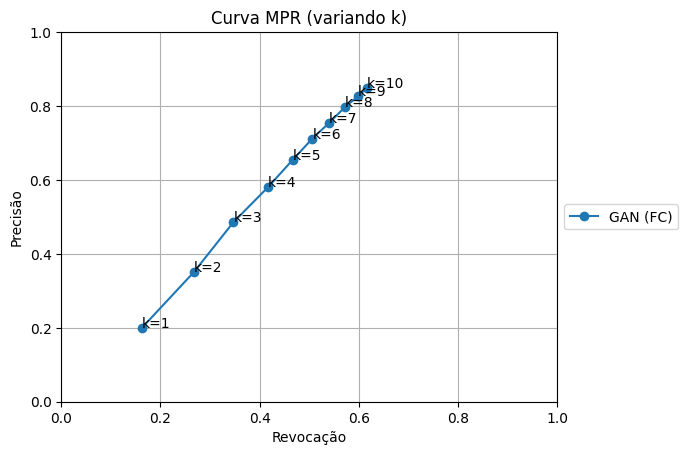

In [42]:
plot_mpr_curve(rec, prec, ks, title='Curva MPR (variando k)')   # Plota a curva MPR de revocação vs. precisão para diferentes valores de k

In [43]:
def mpr_sweep_Nk(
    mnist_test_dataset,
    gen_model,
    feature_extractor,
    Ns=(1000, 2500, 5000, 7500, 10000),
    ks=(3, 5, 10),
    *,
    model_name='GAN (FC)',
    batch_size=512,
    z_dim=None,
    mode_z=None
) -> pd.DataFrame:

    linhas = []                                                                                         # Lista para armazenar resultados intermediários
    for N in Ns:                                                                                        # Itera pelos diferentes valores de N
        real_feats = get_features(mnist_test_dataset, feature_extractor, N=N, batch_size=batch_size)    # Extrai features reais dos primeiros N exemplos
        fake_feats = get_features_from_generator(                                                       # Extrai features de N imagens geradas
            gen_model,
            feature_extractor,
            N=N,
            z_dim=z_dim,
            mode_z=mode_z,
            batch=batch_size
        )
        for k in ks:                                                                             # Itera sobre os diferentes valores de k
            m = compute_prdc(                                                                    # Calcula métricas de precisão e revocação
                real_features=real_feats.astype('float32'),
                fake_features=fake_feats.astype('float32'),
                nearest_k=k
            )
            linhas.append({                                                                      # Adiciona linha com resultados no formato dict
                'modelo':   model_name,
                'N':        int(N),
                'k':        int(k),
                'precision':float(m['precision']),
                'recall':   float(m['recall'])
            })
            print(f"[modelo={model_name}] N={N} | k={k} -> Precisão={m['precision']:.4f} | Revocação={m['recall']:.4f}")  # Exibe no console os resultados do par (N, k)

    return pd.DataFrame(linhas)                                                                  # Retorna um DataFrame com todos os resultados

In [53]:
df_gan = mpr_sweep_Nk(                                           # Executa a varredura de N e k para calcular MPR
    mnist_test_dataset=mnist_test,                               # Conjunto de teste do MNIST usado para extrair features reais
    gen_model=gen_model,                                         # Gerador treinado que produz imagens sintéticas
    feature_extractor=full_model[0],                             # Extrator de características do classificador (parte inicial do modelo)
    Ns=(1000, 2500, 5000, 7500, 10000),                          # Conjunto de valores de N a serem testados
    ks=(3, 5, 10),                                               # Conjunto de valores de k a serem testados
    model_name='GAN (FC)',                                       # Nome do modelo para identificar os resultados no DataFrame
    batch_size=512,                                              # Tamanho dos lotes para processar dados
    z_dim=z_size,                                                # Dimensão do vetor de ruído do gerador
    mode_z=mode_z)                                               # Tipo de ruído usado (normal ou uniforme)

Num real: 1000 Num fake: 1000
[modelo=GAN (FC)] N=1000 | k=3 -> Precisão=0.6910 | Revocação=0.6320
Num real: 1000 Num fake: 1000
[modelo=GAN (FC)] N=1000 | k=5 -> Precisão=0.8570 | Revocação=0.7600
Num real: 1000 Num fake: 1000
[modelo=GAN (FC)] N=1000 | k=10 -> Precisão=0.9630 | Revocação=0.8820
Num real: 2500 Num fake: 2500
[modelo=GAN (FC)] N=2500 | k=3 -> Precisão=0.6376 | Revocação=0.5332
Num real: 2500 Num fake: 2500
[modelo=GAN (FC)] N=2500 | k=5 -> Precisão=0.8060 | Revocação=0.6632
Num real: 2500 Num fake: 2500
[modelo=GAN (FC)] N=2500 | k=10 -> Precisão=0.9440 | Revocação=0.8080
Num real: 5000 Num fake: 5000
[modelo=GAN (FC)] N=5000 | k=3 -> Precisão=0.5680 | Revocação=0.4842
Num real: 5000 Num fake: 5000
[modelo=GAN (FC)] N=5000 | k=5 -> Precisão=0.7414 | Revocação=0.6138
Num real: 5000 Num fake: 5000
[modelo=GAN (FC)] N=5000 | k=10 -> Precisão=0.9126 | Revocação=0.7628
Num real: 7500 Num fake: 7500
[modelo=GAN (FC)] N=7500 | k=3 -> Precisão=0.5404 | Revocação=0.5131
Num rea

In [54]:
display(df_gan)   # Exibe o DataFrame df_gan em formato tabular

,modelo,N,k,precision,recall
0,GAN (FC),1000,3,0.691000,0.632000
1,GAN (FC),1000,5,0.857000,0.760000
2,GAN (FC),1000,10,0.963000,0.882000
3,GAN (FC),2500,3,0.637600,0.533200
4,GAN (FC),2500,5,0.806000,0.663200
5,GAN (FC),2500,10,0.944000,0.808000
6,GAN (FC),5000,3,0.568000,0.484200
7,GAN (FC),5000,5,0.741400,0.613800
8,GAN (FC),5000,10,0.912600,0.762800
9,GAN (FC),7500,3,0.540400,0.513067


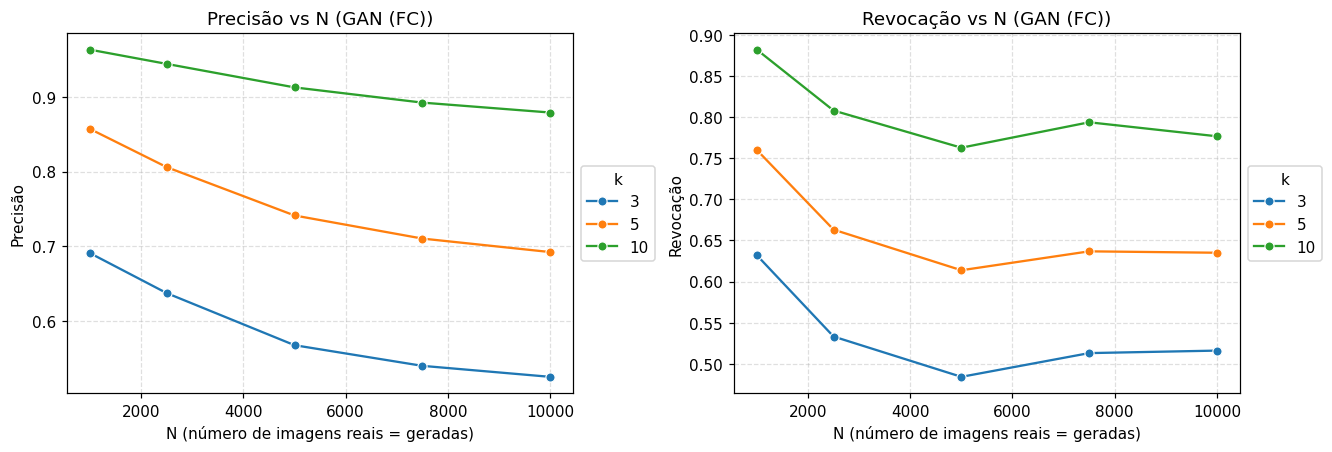

In [55]:
def plot_mpr_df(df: pd.DataFrame):

    modelos = df['modelo'].unique().tolist()                                      # Lista os nomes únicos de modelos presentes no DataFrame
    n_models = len(modelos)                                                       # Conta quantos modelos distintos existem

    fig, axes = plt.subplots(                                                     # Cria figura com subplots
        n_models, 2,                                                              # n_models linhas, 2 colunas (Precisão e Revocação)
        figsize=(12, 4 * n_models),                                               # Ajusta o tamanho da figura proporcional ao número de modelos
        dpi=110,                                                                  # Define resolução em pontos por polegada
        constrained_layout=True                                                   # Ajusta automaticamente os espaçamentos
    )

    if n_models == 1:                                                             # Caso haja apenas 1 modelo
        axes = np.array([axes])                                                   # Garante que axes seja indexável como array bidimensional

    for i, modelo in enumerate(modelos):                                          # Itera sobre cada modelo
        df_model = df[df['modelo'] == modelo].copy()                              # Filtra o DataFrame apenas para esse modelo

        ax_left = axes[i, 0]                                                      # Eixo à esquerda para precisão
        sns.lineplot(                                                             # Plota curva de precisão
            data=df_model, x='N', y='precision',
            hue='k', marker='o', ax=ax_left,
            palette='tab10'
        )
        ax_left.set_title(f'Precisão vs N ({modelo})')                            # Título do gráfico de precisão
        ax_left.set_xlabel('N (número de imagens reais = geradas)')               # Rótulo eixo X
        ax_left.set_ylabel('Precisão')                                            # Rótulo eixo Y
        ax_left.grid(True, linestyle='--', alpha=0.4)                             # Ativa grade com estilo tracejado
        ax_left.legend(loc='center left', bbox_to_anchor=(1, 0.5), title='k')     # Legenda deslocada para a direita

        ax_right = axes[i, 1]                                                     # Eixo à direita para revocação
        sns.lineplot(                                                             # Plota curva de revocação
            data=df_model, x='N', y='recall',
            hue='k', marker='o', ax=ax_right,
            palette='tab10'
        )
        ax_right.set_title(f'Revocação vs N ({modelo})')                          # Título do gráfico de revocação
        ax_right.set_xlabel('N (número de imagens reais = geradas)')              # Rótulo eixo X
        ax_right.set_ylabel('Revocação')                                          # Rótulo eixo Y
        ax_right.grid(True, linestyle='--', alpha=0.4)                            # Ativa grade com estilo tracejado
        ax_right.legend(loc='center left', bbox_to_anchor=(1, 0.5), title='k')    # Legenda deslocada para a direita

    plt.show()                                                                    # Exibe a figura final com todos os subplots

plot_mpr_df(df_gan)   # Plota gráficos de Precisão e Revocação a partir do DataFrame df_gan

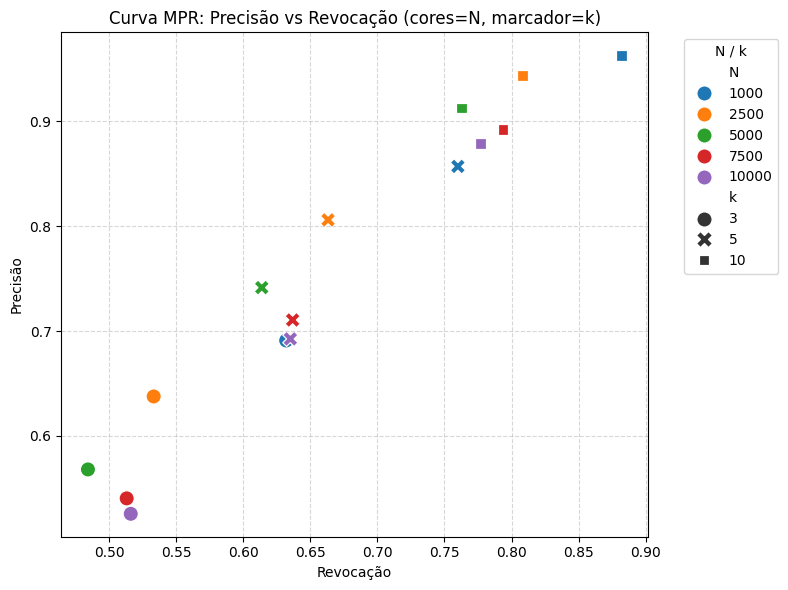

In [56]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_gan,
    x='recall',
    y='precision',
    hue='N',
    style='k',
    s=120,
    palette='tab10'
)
plt.title('Curva MPR: Precisão vs Revocação (cores=N, marcador=k)')
plt.xlabel('Revocação')
plt.ylabel('Precisão')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='N / k')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()